In [1]:
import aplpy
from astropy.io import fits
import astropy.units as u
import astroquery.vizier
from astropy.wcs import WCS

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
spitzer_R = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/Spitzer/M1_cygnus_2.4.fits"
cygnus_NRO_tpeak = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_tpeak.fits"
cygnus_NRO = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/processed_fits/CygnusX_sp16_120-230_integrate_map.fits"
save_png_name = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/make_figure/maked_pictures/RG_linear_linear_30.0_80.0_30.0_100.0_1000000.0_1000000.0.png"

In [3]:
catalogue_path = '/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_Catalogue/cygnus_infer_catalogue.csv' # 提供されたCSVファイル
catalogue_data = pd.read_csv(catalogue_path)

In [4]:
cygnus_hdu = fits.open(cygnus_NRO)[0]
data = cygnus_hdu.data.shape
print(data)

(1593, 2520)


In [7]:
cygnus_cube_hdu = fits.open("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Cygnus-X/NRO45m/Cygnus_sp16_vs-40_ve040_dv0.25_12CO_Tmb.fits")[0]
cygnus_cube_hdu.header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 2520                                                  
NAXIS2  =                 1593                                                  
NAXIS3  =                  320                                                  
OBJECT  = 'Cyg1              '                                                  
TELESCOP= 'NRO45M            '                                                  
INSTRUME= 'TMULTH            '                                                  
OBSERVER= 'bp807an           '                                                  
DATE-OBS= '2016-01-13        '                                                  
DATE-MAP= '2016-09-16        '                                                  
BZERO   =    0.00000000000E+

In [12]:
viz = astroquery.vizier.Vizier(columns=["*"])
viz.ROW_LIMIT = -1
MWP = viz.query_constraints(catalog="2019yCat..74881141J ")[0].to_pandas()

# ⬇️バブルの中に銀河中心を跨ぐものがあった場合、座標がバグる((359.9, 0.01)みたいに。それを(-0.01, 0.01)に変換して防ぐ)
MWP.loc[MWP["GLON"] >= 358.446500015535, "GLON"] -= 360
MWP.index = MWP['MWP'].to_list()

In [13]:
MWP

,MWP,GLON,GLAT,Disp,MajAxis,MinAxis,Reff,e_Reff,theta,e_theta,...,HR3,RelFlag,HierFlag,IDDR1,IDA14,Dist,IDCW,Simbad,_RA.icrs,_DE.icrs
2G0000794-0020817,2G0000794-0020817,0.0794,-0.2082,0.22,0.58,0.49,0.53,0.13,161,133,...,0.18,R,,1G000080-002075,G000.079-00.211,NaN,CN2,Simbad,266.6554,-28.9766
2G0001255+0003035,2G0001255+0003035,0.1255,0.0303,1.01,5.05,4.26,4.67,0.59,87,62,...,0.20,C,,1G000127+000485,G000.132+00.039,NaN,,Simbad,266.4501,-28.8133
2G0001301-0067518,2G0001301-0067518,0.1301,-0.6752,0.20,0.45,0.37,0.41,0.12,24,122,...,0.42,R,,,G000.129-00.674,NaN,CN4,Simbad,267.1427,-29.1749
2G0001400-0011719,2G0001400-0011719,0.1400,-0.1172,0.29,3.14,2.98,3.06,0.37,11,86,...,0.46,C,,1G000140-001173,G000.138-00.115,NaN,,Simbad,266.6025,-28.8776
2G0002791-0048490,2G0002791-0048490,0.2791,-0.4849,0.12,0.42,0.38,0.40,0.23,34,94,...,0.08,R,,,G000.279-00.482,NaN,CN7,Simbad,267.0442,-28.9491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2G3593514-0041492,2G3593514-0041492,-0.6486,-0.4149,0.34,0.44,0.35,0.40,0.24,52,83,...,0.08,C,,1G359350-004141,G359.349-00.417,NaN,,Simbad,266.4237,-29.7059
2G3596901+0006590,2G3596901+0006590,-0.3099,0.0659,0.10,0.59,0.51,0.55,0.06,77,79,...,0.13,C,,,G359.690+00.065,NaN,,Simbad,266.1557,-29.1661
2G3597425-0041121,2G3597425-0041121,-0.2575,-0.4112,0.94,1.97,1.82,1.90,0.68,27,106,...,0.44,R,,1G359737-004097,G359.740-00.412,NaN,CS2,Simbad,266.6538,-29.3700
2G3599224+0011336,2G3599224+0011336,-0.0776,0.1134,0.28,1.08,0.93,1.00,0.31,103,64,...,0.24,C,,,G359.930+00.108,NaN,,Simbad,266.2482,-28.9432


In [14]:
from astropy.coordinates import SkyCoord
import astropy.units as u

hdul = fits.open(spitzer_R)
w = WCS(hdul[0].header)
footprint = w.calc_footprint()

frame_in = 'icrs' if 'RA' in hdul[0].header['CTYPE1'] else 'galactic'

# 2. 4隅の座標を一気に SkyCoord オブジェクトにする
corners = SkyCoord(footprint[:, 0], footprint[:, 1], unit="deg", frame=frame_in)

# 3. 変換してそれぞれの min/max を表示
print(f"--- Equatorial (ICRS) ---")
print(f"RA:  {corners.icrs.ra.deg.min():.4f} to {corners.icrs.ra.deg.max():.4f}")
print(f"Dec: {corners.icrs.dec.deg.min():.4f} to {corners.icrs.dec.deg.max():.4f}")

Spitzer_Glon_Min = corners.galactic.l.deg.min()
Spitzer_Glon_Max = corners.galactic.l.deg.max()
Spitzer_Glat_Min = corners.galactic.b.deg.min()
Spitzer_Glat_Max = corners.galactic.b.deg.max()

print(f"\n--- Galactic ---")
print(f"GLON: {Spitzer_Glon_Min:.4f} to {Spitzer_Glon_Max:.4f}")
print(f"GLAT: {Spitzer_Glat_Min:.4f} to {Spitzer_Glat_Max:.4f}")

--- Equatorial (ICRS) ---
RA:  302.8153 to 312.3546
Dec: 36.2512 to 43.6146

--- Galactic ---
GLON: 73.8590 to 83.8695
GLAT: -4.5046 to 5.4111


In [15]:
MWP_cygnus = MWP.loc[(Spitzer_Glon_Min <= MWP["GLON"]) & (MWP["GLON"] <= Spitzer_Glon_Max)]
MWP_cygnus = MWP_cygnus.loc[(Spitzer_Glat_Min <= MWP["GLAT"]) & (MWP["GLAT"] <= Spitzer_Glat_Max)]

In [16]:
MWP_cygnus

,MWP,GLON,GLAT,Disp,MajAxis,MinAxis,Reff,e_Reff,theta,e_theta,...,HR3,RelFlag,HierFlag,IDDR1,IDA14,Dist,IDCW,Simbad,_RA.icrs,_DE.icrs
2G0757649+0035573,2G0757649+0035573,75.7650,0.3557,0.94,1.08,0.79,0.950000,0.40,68,99,...,0.09,C,,,G075.768+00.344,3.8,,Simbad,305.4077,37.4371
2G0758429+0036690,2G0758429+0036690,75.8429,0.3669,0.28,0.60,0.49,0.550000,0.19,48,81,...,0.18,R,,,G075.844+00.359,1.5,,Simbad,305.4521,37.5075
2G0758992+0035684,2G0758992+0035684,75.8992,0.3569,0.34,1.20,0.67,0.970000,0.11,168,64,...,0.21,C,,,G075.890+00.358,NaN,,Simbad,305.5029,37.5481
2G0761384-0030183,2G0761384-0030183,76.1384,-0.3018,0.86,1.79,1.38,1.600000,0.55,30,101,...,0.38,R,,,G076.139-00.303,NaN,,Simbad,306.3553,37.3658
2G0761874+0054827,2G0761874+0054827,76.1875,0.5483,1.09,2.10,1.57,1.850000,0.70,40,91,...,0.25,R,,,G076.199+00.548,1.5,,Simbad,305.5120,37.8941
2G0761975+0009046,2G0761975+0009046,76.1976,0.0905,1.66,1.73,1.26,1.520000,0.82,67,113,...,0.18,R,,,G076.197+00.092,1.5,,Simbad,305.9942,37.6402
2G0763066-0066423,2G0763066-0066423,76.3067,-0.6642,0.23,0.93,0.64,0.800000,0.27,101,116,...,0.16,R,,,G076.309-00.667,NaN,,Simbad,306.8494,37.2928
2G0763871-0061181,2G0763871-0061181,76.3872,-0.6118,1.19,2.02,0.97,1.580000,0.64,65,71,...,0.33,R,,,G076.384-00.621,1.3,,Simbad,306.8547,37.3887
2G0765436+0197200,2G0765436+0197200,76.5437,1.9720,0.44,1.42,1.07,1.260000,0.26,137,86,...,0.09,C,,,G076.545+01.957,NaN,,Simbad,304.2688,38.9921
2G0769073+0204564,2G0769073+0204564,76.9073,2.0456,0.62,3.35,3.09,3.220000,0.44,62,110,...,0.24,R,D,,G076.917+02.054,1.5,,Simbad,304.4525,39.3344


In [17]:
catalogue_data

,Unnamed: 0,dec_min,ra_min,dec_max,ra_max,width_pix,height_pix
0,0,42.291897,308.650682,42.565254,308.999023,390.0,406.0
1,0,40.799006,307.460314,40.847080,307.523363,71.0,73.0
2,0,38.815480,308.056761,38.854625,308.107591,59.0,59.0
3,0,40.250445,308.097562,40.298526,308.160910,73.0,72.0
4,0,37.276328,306.827304,37.312209,306.873721,55.0,55.0
...,...,...,...,...,...,...,...
73,0,40.202114,305.540874,40.269707,305.628996,99.0,104.0
74,0,39.838105,309.394425,39.879458,309.447556,62.0,61.0
75,0,42.262325,309.294624,42.291281,309.332482,42.0,43.0
76,0,41.954736,309.778572,42.023760,309.871682,106.0,101.0


In [18]:
cy_GLON_center = MWP_cygnus["GLON"].to_numpy() * u.deg
cy_GLAT_center = MWP_cygnus["GLAT"].to_numpy() * u.deg
cy_Reff = MWP_cygnus["Reff"].to_numpy()

coords_galactic = SkyCoord(l=cy_GLON_center, b=cy_GLAT_center, frame='galactic')

# 2. ICRS (RA/Dec) に変換
coords_icrs = coords_galactic.icrs
cy_RA = coords_icrs.ra.deg
cy_DEC = coords_icrs.dec.deg

In [19]:
RA_min = catalogue_data['ra_min']
RA_max = catalogue_data['ra_max']
DEC_min = catalogue_data['dec_min']
DEC_max = catalogue_data['dec_max']
width_pix = catalogue_data['width_pix']

In [20]:
center_ra = (RA_min + RA_max)/2
center_dec = (DEC_min + DEC_max)/2
# radius = (RA_max - RA_min)/2

In [21]:
import numpy as np
from astropy.wcs.utils import proj_plane_pixel_scales

# WCSからピクセルスケールを取得 (度/ピクセル)
# 通常、縦横でほぼ同じなので [0] を使います
pix_scale = proj_plane_pixel_scales(f._wcs)[0]
print(pix_scale)
print(f._wcs.wcs.cunit)

# 1番目の軸（RAやGLON）の単位だけを詳しく見る
unit = f._wcs.wcs.cunit[0]
print(f"Unit: {unit}")

NameError: name 'f' is not defined

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (114786737 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


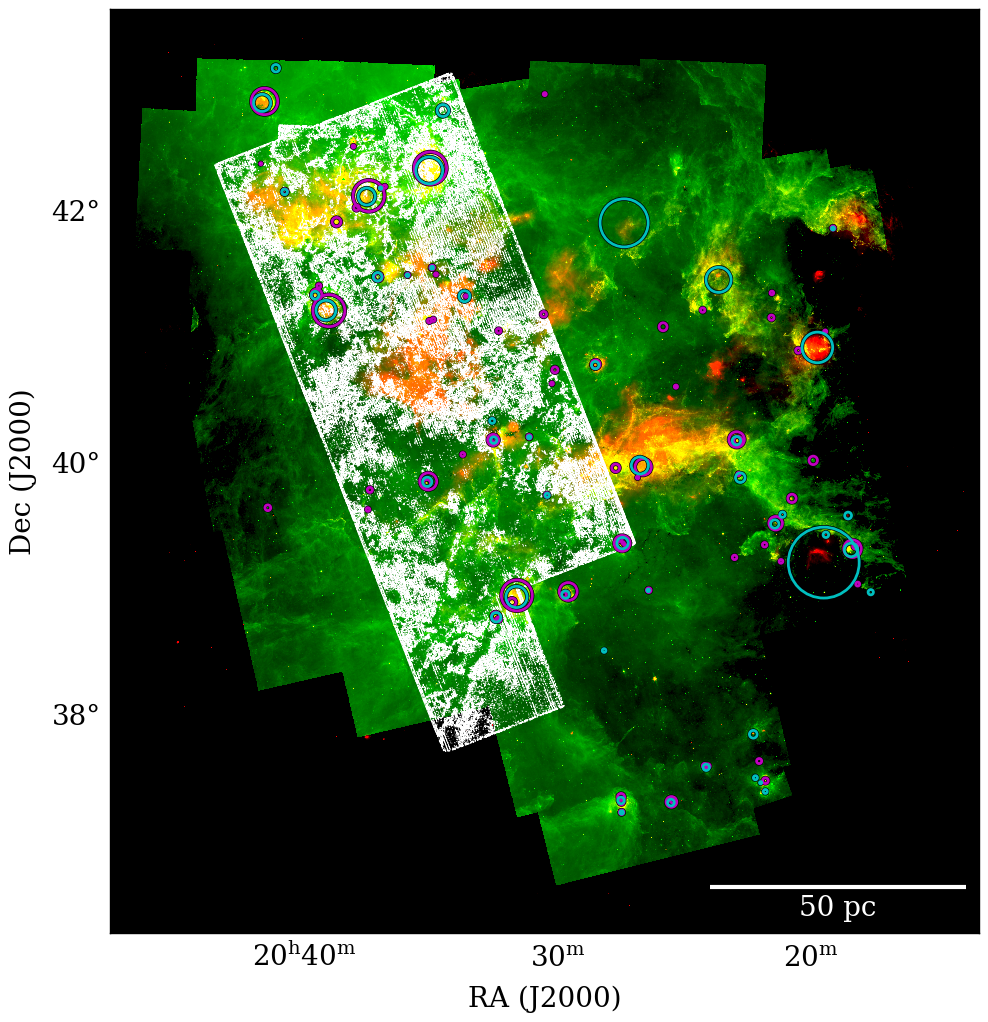

In [69]:
fig = plt.figure(figsize=(16, 12))
f = aplpy.FITSFigure(spitzer_R, slices=[0], figure=fig, convention='wells')
f.show_rgb(save_png_name)
f.ticks.set_color('w')
f.tick_labels.set_font(size=20, family='serif')
f.axis_labels.set_font(size=20, family='serif')

pix_scale = proj_plane_pixel_scales(f._wcs)[0]

for i, (ra, dec) in enumerate(zip(center_ra, center_dec)):
    f.show_circles(ra, dec, width_pix[i]*pix_scale/2, coords_frame='world', color="k", linestyle="-", linewidth=3, zorder=103)
    f.show_circles(ra, dec, width_pix[i]*pix_scale/2, coords_frame='world', color="m", linestyle="-", linewidth=2, zorder=105)

for i, (ra, dec) in enumerate(zip(cy_RA, cy_DEC)):
    f.show_circles(ra, dec, cy_Reff[i]/60, coords_frame='world', color="k", linestyle="-", linewidth=3, zorder=103)
    f.show_circles(ra, dec, cy_Reff[i]/60, coords_frame='world', color="c", linestyle="-", linewidth=2, zorder=105)

levels = [30, 120]
f.show_contour(cygnus_NRO, levels=levels, linewidths=0.5, colors="white", zorder=100) # もしくはファイル名

f.add_scalebar(np.rad2deg(np.arcsin(50.0/1400)))
f.scalebar.set_label('50 pc')
f.scalebar.set_font_family('serif')
f.scalebar.set_font_size(20)
f.scalebar.set_color("w")
f.scalebar.set_linewidth(3)

# f.save('RGB_aplpy.pdf', dpi=300)